# Western US Aquifer Regions — Dominant Irrigation Water Source by Timeline
## Literature Review and Synthesis: 1985–2025

**Purpose:** This notebook catalogs the dominant irrigation water source type (groundwater, surface water, or conjunctive use) for major aquifer regions visible in the `aquifers_by_state` shapefile across three temporal windows:
- **Period 1:** 1985–2000
- **Period 2:** 2000–2010
- **Period 3:** 2010–2025

For conjunctive-use regions, the approximate **surface water : groundwater ratio** is reported where available.

**Shapefile path:**
```
/Users/mdfahimhasan/Documents/PROJECTS/WestUS_IWU_trend/Data_main/ref_shapes/aquifers_ROI/aquifers_by_state.shp
```

**Compiled by:** Literature review of USGS, USDA, state agency, and peer-reviewed sources, April 2026.
    
---

## 1. Setup — Load Shapefile and Inspect Regions

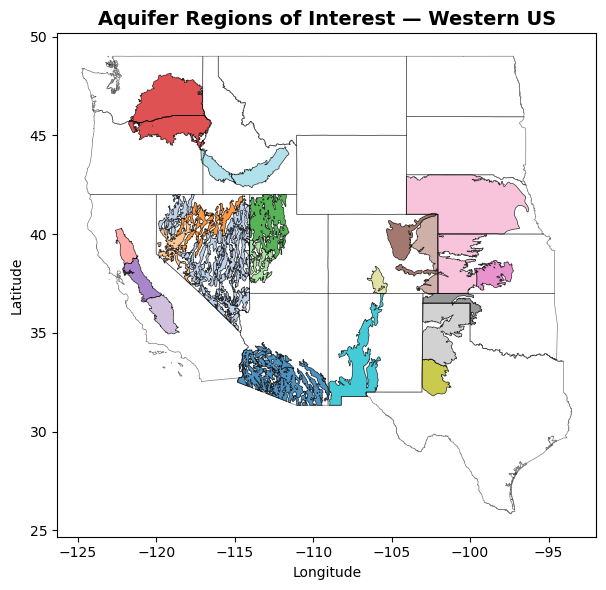

In [17]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load the shapefile
shp_path = '/Users/mdfahimhasan/Documents/PROJECTS/WestUS_IWU_trend/Data_main/ref_shapes/aquifers_ROI/aquifers_by_state.shp'
west_us_shp = '/Users/mdfahimhasan/Documents/PROJECTS/WestUS_IWU_trend/Data_main/ref_shapes/WestUS_states.shp'
gdf = gpd.read_file(shp_path)
west_us_gdf = gpd.read_file(west_us_shp)

# Quick map of study regions
fig, ax = plt.subplots(figsize=(8, 6))
gdf.plot(ax=ax, column=gdf['AQ_Region'],
         cmap='tab20', edgecolor='black', linewidth=0.5, alpha=0.8)
west_us_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5, alpha=0.5)
ax.set_title('Aquifer Regions of Interest — Western US', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()

---
## 2. Literature-Derived Data — Irrigation Water Source by Region and Timeline

The table below synthesizes findings from USGS Circulars, USDA FRIS/IWMS surveys, and peer-reviewed studies.
Dominant source is classified **programmatically** from the literature-derived `GW_pct` using:

```python
# < 30% GW use  →  0  (Surface Water)
# 30–60% GW use →  1  (Conjunctive)
# ≥ 60% GW use  →  2  (Groundwater)
```

> **Note on conjunctive ratios:** Ratios are expressed as SW%:GW% of total irrigation water applied.
> Where ratios vary by drought/wet year, both extremes are noted in the `Notes` column.

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# COMPILED LITERATURE DATA  (raw GW%/SW% from sources)
#
# Confidence levels:
#   High   — primary quantitative source, good period coverage
#   Medium — primary source covers part of period; or secondary source
#   Low    — limited source coverage; estimate only
# ─────────────────────────────────────────────────────────────────────────────

data = [
    # ════════════════════════════════════════════════════════════════════
    # CALIFORNIA — CENTRAL VALLEY
    # ════════════════════════════════════════════════════════════════════
    {
        'Region': 'Central Valley — Sacramento Valley',
        'State(s)': 'CA',
        'Period': '1985–2000',
        'SW_pct': 68, 'GW_pct': 32,
        'Confidence': 'High',
        'Data_Ref': 'Faunt et al. (2009) USGS PP-1766, Table B3',
        'Notes': 'GW = 32% in 1985. SWP/CVP surface water dominant; during dry years GW share rises to ~50-60%.',
        'Key Source': 'Faunt et al. (2009) USGS PP-1766, Table B3',
    },
    {
        'Region': 'Central Valley — Sacramento Valley',
        'State(s)': 'CA',
        'Period': '2000–2010',
        'SW_pct': 67, 'GW_pct': 33,
        'Confidence': 'High',
        'Data_Ref': ('https://www.scienceforconservation.org/assets/downloads/GroundwaterStreamInteraction_2016.pdf; '
                     'https://ca.water.usgs.gov/projects/central-valley/sacramento-valley.html; '
                     'https://www.norcalwater.org/res/docs/NCWA_supp-web.pdf; '
                     'Faunt et al. (2009) USGS PP-1766, Table B3'),
        'Notes': '',
        'Key Source': 'https://www.scienceforconservation.org/assets/downloads/GroundwaterStreamInteraction_2016.pdf',
    },
    {
        'Region': 'Central Valley — Sacramento Valley',
        'State(s)': 'CA',
        'Period': '2010–2025',
        'SW_pct': 67, 'GW_pct': 33,
        'Confidence': 'High',
        'Data_Ref': ('https://www.scienceforconservation.org/assets/downloads/GroundwaterStreamInteraction_2016.pdf; '
                     'https://ca.water.usgs.gov/projects/central-valley/sacramento-valley.html; '
                     'https://www.norcalwater.org/res/docs/NCWA_supp-web.pdf; '
                     'Faunt et al. (2009) USGS PP-1766, Table B3'),
        'Notes': '',
        'Key Source': 'https://www.scienceforconservation.org/assets/downloads/GroundwaterStreamInteraction_2016.pdf',
    },

    {
        'Region': 'Central Valley — San Joaquin Valley',
        'State(s)': 'CA',
        'Period': '1985–2000',
        'SW_pct': 55, 'GW_pct': 45,
        'Confidence': 'High',
        'Data_Ref': 'Faunt et al. (2009) USGS PP-1766, Table B3',
        'Notes': '',
        'Key Source': 'Faunt et al. (2009) USGS PP-1766',
    },
    {
        'Region': 'Central Valley — San Joaquin Valley',
        'State(s)': 'CA',
        'Period': '2000–2010',
        'SW_pct': 55, 'GW_pct': 45,
        'Confidence': 'Medium',
        'Data_Ref': ('https://www.scienceforconservation.org/assets/downloads/GroundwaterStreamInteraction_2016.pdf; '
                     'https://ca.water.usgs.gov/projects/central-valley/san-joaquin-basin.html; '
                     'Faunt et al. (2009) USGS PP-1766, Table B3'),
        'Notes': '',
        'Key Source': 'https://www.scienceforconservation.org/assets/downloads/GroundwaterStreamInteraction_2016.pdf',
    },
    {
        'Region': 'Central Valley — San Joaquin Valley',
        'State(s)': 'CA',
        'Period': '2010–2025',
        'SW_pct': 55, 'GW_pct': 45,
        'Confidence': 'Medium',
        'Data_Ref': ('https://www.scienceforconservation.org/assets/downloads/GroundwaterStreamInteraction_2016.pdf; '
                     'https://ca.water.usgs.gov/projects/central-valley/san-joaquin-basin.html; '
                     'Faunt et al. (2009) USGS PP-1766, Table B3'),
        'Notes': 'The ratio can dramatically shift in dry years, with GW share rising to 60-70%.',
        'Key Source': 'https://www.scienceforconservation.org/assets/downloads/GroundwaterStreamInteraction_2016.pdf',
    },

    {
        'Region': 'Central Valley — Tulare Lake Basin',
        'State(s)': 'CA',
        'Period': '1985–2000',
        'SW_pct': 48, 'GW_pct': 52,
        'Confidence': 'High',
        'Data_Ref': ('https://www.scienceforconservation.org/assets/downloads/GroundwaterStreamInteraction_2016.pdf; '
                     'Faunt et al. (2009) USGS PP-1766, Table B3'),
        'Notes': 'Tulare Lake Basin is the most GW-stressed CV subregion. Limited SWP/CVP deliveries.',
        'Key Source': 'https://www.scienceforconservation.org/assets/downloads/GroundwaterStreamInteraction_2016.pdf',
    },
    {
        'Region': 'Central Valley — Tulare Lake Basin',
        'State(s)': 'CA',
        'Period': '2000–2010',
        'SW_pct': 46, 'GW_pct': 54,
        'Confidence': 'Medium',
        'Data_Ref': ('https://www.scienceforconservation.org/assets/downloads/GroundwaterStreamInteraction_2016.pdf; '
                     'Faunt et al. (2009) USGS PP-1766, Table B3'),
        'Notes': 'Tulare Lake Basin is the most GW-stressed CV subregion. Limited SWP/CVP deliveries.',
        'Key Source': 'https://www.scienceforconservation.org/assets/downloads/GroundwaterStreamInteraction_2016.pdf',
    },
    {
        'Region': 'Central Valley — Tulare Lake Basin',
        'State(s)': 'CA',
        'Period': '2010–2025',
        'SW_pct': 48, 'GW_pct': 52,
        'Confidence': 'Medium',
        'Data_Ref': ('https://www.scienceforconservation.org/assets/downloads/GroundwaterStreamInteraction_2016.pdf; '
                     'Faunt et al. (2009) USGS PP-1766, Table B3'),
        'Notes': 'Tulare Lake Basin is the most GW-stressed CV subregion. Limited SWP/CVP deliveries.',
        'Key Source': 'https://www.scienceforconservation.org/assets/downloads/GroundwaterStreamInteraction_2016.pdf',
    },

    # ════════════════════════════════════════════════════════════════════
    # ARID SOUTHWEST
    # ════════════════════════════════════════════════════════════════════
    {
        'Region': 'Arizona AMAs (Tucson, Pinal)',
        'State(s)': 'AZ',
        'Period': '1985–2000',
        'SW_pct': 28, 'GW_pct': 72,
        'Confidence': 'High',
        'Data_Ref': 'ADWR AMA Annual Supply and Demand Dashboard - https://www.azwater.gov/ama/ama-data',
        'Notes': '',
        'Key Source': 'ADWR AMA Annual Supply and Demand Dashboard - https://www.azwater.gov/ama/ama-data',
    },
    {
        'Region': 'Arizona AMAs (Tucson, Pinal)',
        'State(s)': 'AZ',
        'Period': '2000–2010',
        'SW_pct': 44, 'GW_pct': 56,
        'Confidence': 'High',
        'Data_Ref': 'ADWR AMA Annual Supply and Demand Dashboard - https://www.azwater.gov/ama/ama-data',
        'Notes': '',
        'Key Source': 'ADWR AMA Annual Supply and Demand Dashboard - https://www.azwater.gov/ama/ama-data',
    },
    {
        'Region': 'Arizona AMAs (Tucson, Pinal)',
        'State(s)': 'AZ',
        'Period': '2010–2025',
        'SW_pct': 52, 'GW_pct': 48,
        'Confidence': 'High',
        'Data_Ref': 'ADWR AMA Annual Supply and Demand Dashboard - https://www.azwater.gov/ama/ama-data',
        'Notes': '',
        'Key Source': 'ADWR AMA Annual Supply and Demand Dashboard - https://www.azwater.gov/ama/ama-data',
    },
    {
        'Region': 'Arizona AMAs (Phoenix, Prescott, Santa Cruz)',
        'State(s)': 'AZ',
        'Period': '1985–2000',
        'SW_pct': 45, 'GW_pct': 55,
        'Confidence': 'High',
        'Data_Ref': 'ADWR AMA Annual Supply and Demand Dashboard - https://www.azwater.gov/ama/ama-data',
        'Notes': '',
        'Key Source': 'ADWR AMA Annual Supply and Demand Dashboard - https://www.azwater.gov/ama/ama-data',
    },
    {
        'Region': 'Arizona AMAs (Phoenix, Prescott, Santa Cruz)',
        'State(s)': 'AZ',
        'Period': '2000–2010',
        'SW_pct': 62, 'GW_pct': 38,
        'Confidence': 'High',
        'Data_Ref': 'ADWR AMA Annual Supply and Demand Dashboard - https://www.azwater.gov/ama/ama-data',
        'Notes': '',
        'Key Source': 'ADWR AMA Annual Supply and Demand Dashboard - https://www.azwater.gov/ama/ama-data',
    },
    {
        'Region': 'Arizona AMAs (Phoenix, Prescott, Santa Cruz)',
        'State(s)': 'AZ',
        'Period': '2010–2025',
        'SW_pct': 67, 'GW_pct': 33,
        'Confidence': 'High',
        'Data_Ref': 'ADWR AMA Annual Supply and Demand Dashboard - https://www.azwater.gov/ama/ama-data',
        'Notes': '',
        'Key Source': 'ADWR AMA Annual Supply and Demand Dashboard - https://www.azwater.gov/ama/ama-data',
    },
    {
        'Region': 'Nevada West',
        'State(s)': 'NV',
        'Period': '1985–2000',
        'SW_pct': 50, 'GW_pct': 50,
        'Confidence': 'Low',
        'Data_Ref': 'Lopes & Evetts (2004); https://www.tcid.org/about',
        'Notes': 'Not confident about the ratio split. Truckee and Carson Basins are more SW dominated, while Walker basin is more GW dominated.',
        'Key Source': 'Lopes & Evetts (2004)',
    },
    {
        'Region': 'Nevada West',
        'State(s)': 'NV',
        'Period': '2000–2010',
        'SW_pct': 50, 'GW_pct': 50,
        'Confidence': 'Low',
        'Data_Ref': 'Lopes & Evetts (2004); https://www.tcid.org/about',
        'Notes': 'Not confident about the ratio split. Truckee and Carson Basins are more SW dominated, while Walker basin is more GW dominated.',
        'Key Source': 'Lopes & Evetts (2004)',
    },
    {
        'Region': 'Nevada West',
        'State(s)': 'NV',
        'Period': '2010–2025',
        'SW_pct': 50, 'GW_pct': 50,
        'Confidence': 'Low',
        'Data_Ref': 'Lopes & Evetts (2004); https://www.tcid.org/about',
        'Notes': 'Not confident about the ratio split. Truckee and Carson Basins are more SW dominated, while Walker basin is more GW dominated.',
        'Key Source': 'Lopes & Evetts (2004)',
    },
    {
        'Region': 'Nevada North',
        'State(s)': 'NV',
        'Period': '1985–2000',
        'SW_pct': 50, 'GW_pct': 50,
        'Confidence': 'Low',
        'Data_Ref': 'Lopes & Evetts (2004); https://www.usbr.gov/projects/index.php?id=463',
        'Notes': 'Not confident about the ratio split.',
        'Key Source': 'Lopes & Evetts (2004)',
    },
    {
        'Region': 'Nevada North',
        'State(s)': 'NV',
        'Period': '2000–2010',
        'SW_pct': 50, 'GW_pct': 50,
        'Confidence': 'Low',
        'Data_Ref': 'Lopes & Evetts (2004); https://www.usbr.gov/projects/index.php?id=463',
        'Notes': 'Not confident about the ratio split.',
        'Key Source': 'Lopes & Evetts (2004)',
    },
    {
        'Region': 'Nevada North',
        'State(s)': 'NV',
        'Period': '2010–2025',
        'SW_pct': 50, 'GW_pct': 50,
        'Confidence': 'Low',
        'Data_Ref': 'Lopes & Evetts (2004); https://www.usbr.gov/projects/index.php?id=463',
        'Notes': 'Not confident about the ratio split.',
        'Key Source': 'Lopes & Evetts (2004)',
    },
    {
        'Region': 'Nevada Central and Northwest',
        'State(s)': 'NV',
        'Period': '1985–2000',
        'SW_pct': 20, 'GW_pct': 80,
        'Confidence': 'Low',
        'Data_Ref': ('Lopes & Evetts (2004); '
                     'https://www.usgs.gov/centers/nevada-water-science-center/science/budgets-and-chemical-characterization-groundwater'),
        'Notes': 'Not confident about the ratio split. Mostly closed basins with no surface water outflow; likely more groundwater dominated.',
        'Key Source': 'Lopes & Evetts (2004)',
    },
    {
        'Region': 'Nevada Central and Northwest',
        'State(s)': 'NV',
        'Period': '2000–2010',
        'SW_pct': 20, 'GW_pct': 80,
        'Confidence': 'Low',
        'Data_Ref': ('Lopes & Evetts (2004); '
                     'https://www.usgs.gov/centers/nevada-water-science-center/science/budgets-and-chemical-characterization-groundwater'),
        'Notes': 'Not confident about the ratio split. Mostly closed basins with no surface water outflow; likely more groundwater dominated.',
        'Key Source': 'Lopes & Evetts (2004)',
    },
    {
        'Region': 'Nevada Central and Northwest',
        'State(s)': 'NV',
        'Period': '2010–2025',
        'SW_pct': 20, 'GW_pct': 80,
        'Confidence': 'Low',
        'Data_Ref': ('Lopes & Evetts (2004); '
                     'https://www.usgs.gov/centers/nevada-water-science-center/science/budgets-and-chemical-characterization-groundwater'),
        'Notes': 'Not confident about the ratio split. Mostly closed basins with no surface water outflow; likely more groundwater dominated.',
        'Key Source': 'Lopes & Evetts (2004)',
    },

    # ════════════════════════════════════════════════════════════════════
    # SAN LUIS VALLEY (CO)
    # ════════════════════════════════════════════════════════════════════
    {
        'Region': 'San Luis Valley (CO)',
        'State(s)': 'CO',
        'Period': '1985–2000',
        'SW_pct': 50, 'GW_pct': 50,
        'Confidence': 'High',
        'Data_Ref': 'Ivahnenko et al. (2021) USGS SIR 2021-5036, Table 8, 9 and Figure 5',
        'Notes': 'Assigned 50-50: SW is recharged to aquifer and later withdrawn for irrigation.',
        'Key Source': 'Ivahnenko et al. (2021) USGS SIR 2021-5036; CO DWR Division 3; Fatta et al. 2026',
    },
    {
        'Region': 'San Luis Valley (CO)',
        'State(s)': 'CO',
        'Period': '2000–2010',
        'SW_pct': 50, 'GW_pct': 50,
        'Confidence': 'High',
        'Data_Ref': 'Ivahnenko et al. (2021) USGS SIR 2021-5036, Table 8, 9 and Figure 5',
        'Notes': 'Assigned 50-50: SW is recharged to aquifer and later withdrawn for irrigation.',
        'Key Source': 'Ivahnenko et al. (2021) USGS SIR 2021-5036; CO DWR Division 3; Fatta et al. 2026',
    },
    {
        'Region': 'San Luis Valley (CO)',
        'State(s)': 'CO',
        'Period': '2010–2025',
        'SW_pct': 50, 'GW_pct': 50,
        'Confidence': 'High',
        'Data_Ref': 'Ivahnenko et al. (2021) USGS SIR 2021-5036, Table 8, 9 and Figure 5',
        'Notes': 'Assigned 50-50: SW is recharged to aquifer and later withdrawn for irrigation.',
        'Key Source': 'Ivahnenko et al. (2021) USGS SIR 2021-5036; CO DWR Division 3; Fatta et al. 2026',
    },

    # ════════════════════════════════════════════════════════════════════
    # RIO GRANDE BASIN (NM)
    # ════════════════════════════════════════════════════════════════════
    {
        'Region': 'Rio Grande Basin (NM)',
        'State(s)': 'NM',
        'Period': '1985–2000',
        'SW_pct': 86, 'GW_pct': 14,
        'Confidence': 'High',
        'Data_Ref': 'Ivahnenko et al. (2021) USGS SIR 2021-5036, Table 8, 9 and Figure 5',
        'Notes': 'Rio Grande Project (BOR) provides most SW for irrigation in NM.',
        'Key Source': 'Ivahnenko et al. (2021) USGS SIR 2021-5036',
    },
    {
        'Region': 'Rio Grande Basin (NM)',
        'State(s)': 'NM',
        'Period': '2000–2010',
        'SW_pct': 82, 'GW_pct': 18,
        'Confidence': 'High',
        'Data_Ref': 'Ivahnenko et al. (2021) USGS SIR 2021-5036, Table 8, 9 and Figure 5',
        'Notes': 'Rio Grande Project (BOR) provides most SW for irrigation in NM.',
        'Key Source': 'Ivahnenko et al. (2021) USGS SIR 2021-5036',
    },
    {
        'Region': 'Rio Grande Basin (NM)',
        'State(s)': 'NM',
        'Period': '2010–2025',
        'SW_pct': 71, 'GW_pct': 29,
        'Confidence': 'High',
        'Data_Ref': 'Ivahnenko et al. (2021) USGS SIR 2021-5036, Table 8, 9 and Figure 5',
        'Notes': 'Rio Grande Project (BOR) provides most SW for irrigation in NM.',
        'Key Source': 'Ivahnenko et al. (2021) USGS SIR 2021-5036',
    },

    # ════════════════════════════════════════════════════════════════════
    # HIGH PLAINS AQUIFER
    # ════════════════════════════════════════════════════════════════════
    {
        'Region': 'High Plains Aquifer (western — CO/TX/KS/WY)',
        'State(s)': 'CO / TX / KS / WY',
        'Period': '1985–2000',
        'SW_pct': 5, 'GW_pct': 95,
        'Confidence': 'High',
        'Data_Ref': 'McGuire et al. (2011) and (2023)',
        'Notes': "McGuire et al. doesn't give a specific number, but the Ogallala aquifer is overwhelmingly groundwater irrigated.",
        'Key Source': 'McGuire et al. (2011) and (2023)',
    },
    {
        'Region': 'High Plains Aquifer (western — CO/TX/KS/WY)',
        'State(s)': 'CO / TX / KS / WY',
        'Period': '2000–2010',
        'SW_pct': 5, 'GW_pct': 95,
        'Confidence': 'High',
        'Data_Ref': 'McGuire et al. (2011) and (2023)',
        'Notes': "McGuire et al. doesn't give a specific number, but the Ogallala aquifer is overwhelmingly groundwater irrigated.",
        'Key Source': 'McGuire et al. (2011) and (2023)',
    },
    {
        'Region': 'High Plains Aquifer (western — CO/TX/KS/WY)',
        'State(s)': 'CO / TX / KS / WY',
        'Period': '2010–2025',
        'SW_pct': 5, 'GW_pct': 95,
        'Confidence': 'High',
        'Data_Ref': 'McGuire et al. (2011) and (2023)',
        'Notes': "McGuire et al. doesn't give a specific number, but the Ogallala aquifer is overwhelmingly groundwater irrigated.",
        'Key Source': 'McGuire et al. (2011) and (2023)',
    },

    # ════════════════════════════════════════════════════════════════════
    # UTAH
    # ════════════════════════════════════════════════════════════════════
    {
        'Region': 'UT South',
        'State(s)': 'UT',
        'Period': '1985–2000',
        'SW_pct': 30, 'GW_pct': 70,
        'Confidence': 'High',
        'Data_Ref': ('https://pubs.usgs.gov/sir/2017/5033/sir20175033.pdf; '
                     'https://pubs.usgs.gov/sir/2005/5170/PDF/SIR2005_5170.pdf; '
                     'https://pubs.usgs.gov/sir/2019/5139/sir20195139.pdf'),
        'Notes': 'Based on Parowan Valley. Cedar, Pine, and Wah Wah valleys confirm groundwater is the dominant source.',
        'Key Source': 'Marston et al. 2017; Brooks and Marston 2005; Gardner et al. 2019',
    },
    {
        'Region': 'UT South',
        'State(s)': 'UT',
        'Period': '2000–2010',
        'SW_pct': 30, 'GW_pct': 70,
        'Confidence': 'High',
        'Data_Ref': ('https://pubs.usgs.gov/sir/2017/5033/sir20175033.pdf; '
                     'https://pubs.usgs.gov/sir/2005/5170/PDF/SIR2005_5170.pdf; '
                     'https://pubs.usgs.gov/sir/2019/5139/sir20195139.pdf'),
        'Notes': 'Based on Parowan Valley. Cedar, Pine, and Wah Wah valleys confirm groundwater is the dominant source.',
        'Key Source': 'Marston et al. 2017; Brooks and Marston 2005; Gardner et al. 2019',
    },
    {
        'Region': 'UT South',
        'State(s)': 'UT',
        'Period': '2010–2025',
        'SW_pct': 30, 'GW_pct': 70,
        'Confidence': 'High',
        'Data_Ref': ('https://pubs.usgs.gov/sir/2017/5033/sir20175033.pdf; '
                     'https://pubs.usgs.gov/sir/2005/5170/PDF/SIR2005_5170.pdf; '
                     'https://pubs.usgs.gov/sir/2019/5139/sir20195139.pdf'),
        'Notes': 'Based on Parowan Valley. Cedar, Pine, and Wah Wah valleys confirm groundwater is the dominant source.',
        'Key Source': 'Marston et al. 2017; Brooks and Marston 2005; Gardner et al. 2019',
    },
    {
        'Region': 'UT North',
        'State(s)': 'UT',
        'Period': '1985–2000',
        'SW_pct': 90, 'GW_pct': 10,
        'Confidence': 'High',
        'Data_Ref': ('https://water.utah.gov/wp-content/uploads/2019/SWP/JordanRiver/Jordan-River-Basin-Final2010.pdf; '
                     'https://d36oiwf74r1rap.cloudfront.net/wp-content/uploads/2015/09/Jul-Aug-2004.pdf'),
        'Notes': 'Based on Wasatch Front. In Jordan River valley, estimated GW irrigation is 3%.',
        'Key Source': 'UDWR 2010; Isaacson 2004',
    },
    {
        'Region': 'UT North',
        'State(s)': 'UT',
        'Period': '2000–2010',
        'SW_pct': 90, 'GW_pct': 10,
        'Confidence': 'High',
        'Data_Ref': ('https://water.utah.gov/wp-content/uploads/2019/SWP/JordanRiver/Jordan-River-Basin-Final2010.pdf; '
                     'https://d36oiwf74r1rap.cloudfront.net/wp-content/uploads/2015/09/Jul-Aug-2004.pdf'),
        'Notes': 'Based on Wasatch Front. In Jordan River valley, estimated GW irrigation is 3%.',
        'Key Source': 'UDWR 2010; Isaacson 2004',
    },
    {
        'Region': 'UT North',
        'State(s)': 'UT',
        'Period': '2010–2025',
        'SW_pct': 90, 'GW_pct': 10,
        'Confidence': 'High',
        'Data_Ref': ('https://water.utah.gov/wp-content/uploads/2019/SWP/JordanRiver/Jordan-River-Basin-Final2010.pdf; '
                     'https://d36oiwf74r1rap.cloudfront.net/wp-content/uploads/2015/09/Jul-Aug-2004.pdf'),
        'Notes': 'Based on Wasatch Front. In Jordan River valley, estimated GW irrigation is 3%.',
        'Key Source': 'UDWR 2010; Isaacson 2004',
    },

    # ════════════════════════════════════════════════════════════════════
    # PACIFIC NORTHWEST
    # ════════════════════════════════════════════════════════════════════
    {
        'Region': 'Columbia Plateau',
        'State(s)': 'WA / OR / ID',
        'Period': '1985–2000',
        'SW_pct': 74, 'GW_pct': 26,
        'Confidence': 'High',
        'Data_Ref': 'Kahle et al. (2011) USGS SIR 2011-5124, Figure 9',
        'Notes': 'Reports cover 1985-2007. GW-SW split is relatively stable.',
        'Key Source': 'Kahle et al. (2011) USGS SIR 2011-5124',
    },
    {
        'Region': 'Columbia Plateau',
        'State(s)': 'WA / OR / ID',
        'Period': '2000–2010',
        'SW_pct': 74, 'GW_pct': 26,
        'Confidence': 'High',
        'Data_Ref': 'Kahle et al. (2011) USGS SIR 2011-5124, Figure 9',
        'Notes': 'Reports cover 1985-2007. GW-SW split is relatively stable.',
        'Key Source': 'Kahle et al. (2011) USGS SIR 2011-5124',
    },
    {
        'Region': 'Columbia Plateau',
        'State(s)': 'WA / OR / ID',
        'Period': '2010–2025',
        'SW_pct': 74, 'GW_pct': 26,
        'Confidence': 'High',
        'Data_Ref': 'Kahle et al. (2011) USGS SIR 2011-5124, Figure 9',
        'Notes': 'Reports cover 1985-2007. GW-SW split is relatively stable.',
        'Key Source': 'Kahle et al. (2011) USGS SIR 2011-5124',
    },
    {
        'Region': 'Snake River Plain - East',
        'State(s)': 'ID',
        'Period': '1985–2000',
        'SW_pct': 53, 'GW_pct': 47,
        'Confidence': 'High',
        'Data_Ref': 'Clark et al. (1998)',
        'Notes': 'Somewhat old source, but the only one providing a detailed split of irrigation by water source.',
        'Key Source': 'Clark et al. (1998)',
    },
    {
        'Region': 'Snake River Plain - East',
        'State(s)': 'ID',
        'Period': '2000–2010',
        'SW_pct': 53, 'GW_pct': 47,
        'Confidence': 'High',
        'Data_Ref': 'Clark et al. (1998)',
        'Notes': 'Somewhat old source, but the only one providing a detailed split of irrigation by water source.',
        'Key Source': 'Clark et al. (1998)',
    },
    {
        'Region': 'Snake River Plain - East',
        'State(s)': 'ID',
        'Period': '2010–2025',
        'SW_pct': 53, 'GW_pct': 47,
        'Confidence': 'High',
        'Data_Ref': 'Clark et al. (1998)',
        'Notes': 'Somewhat old source, but the only one providing a detailed split of irrigation by water source.',
        'Key Source': 'Clark et al. (1998)',
    },
    {
        'Region': 'Snake River Plain - West',
        'State(s)': 'ID',
        'Period': '1985–2000',
        'SW_pct': 71, 'GW_pct': 29,
        'Confidence': 'Medium',
        'Data_Ref': 'Clark et al. (1998)',
        'Notes': 'The West of the Snake River Plain has more surface water irrigation than the East.',
        'Key Source': 'Clark et al. (1998); Idaho Water Use, 2015 - Fact Sheet',
    },
    {
        'Region': 'Snake River Plain - West',
        'State(s)': 'ID',
        'Period': '2000–2010',
        'SW_pct': 71, 'GW_pct': 29,
        'Confidence': 'Medium',
        'Data_Ref': 'Clark et al. (1998)',
        'Notes': 'The West of the Snake River Plain has more surface water irrigation than the East.',
        'Key Source': 'Clark et al. (1998); Idaho Water Use, 2015 - Fact Sheet',
    },
    {
        'Region': 'Snake River Plain - West',
        'State(s)': 'ID',
        'Period': '2010–2025',
        'SW_pct': 71, 'GW_pct': 29,
        'Confidence': 'Medium',
        'Data_Ref': 'Clark et al. (1998)',
        'Notes': 'The West of the Snake River Plain has more surface water irrigation than the East.',
        'Key Source': 'Clark et al. (1998); Idaho Water Use, 2015 - Fact Sheet',
    },

    # ════════════════════════════════════════════════════════════════════
    # COLORADO — EASTERN BASINS (CDSS/CDWR irrigated-area data)
    # Source: hand-calculated from CO CDSS flood vs. sprinkler acreage
    #   (flood ≈ surface water; sprinkler ≈ groundwater)
    #   Snapshot years available: 2010, 2015, 2020
    #   P1 proxy = 2010 value (no pre-2010 CDSS split data)
    # ════════════════════════════════════════════════════════════════════
    {
        'Region': 'Denver Basin (South Platte, CO)',
        'State(s)': 'CO',
        'Period': '1985–2000',
        'SW_pct': 77, 'GW_pct': 23,
        'Confidence': 'Medium',
        'Data_Ref': 'CO CDSS irrigated-area data (flood vs. sprinkler, 2010 proxy) - https://cdss.colorado.gov/',
        'Notes': 'No pre-2010 method-split data available. 2010 value used as proxy. Flood=SW, Sprinkler≈GW.',
        'Key Source': 'CO CDSS / CDWR — hand-calculated from irrigated area by method',
    },
    {
        'Region': 'Denver Basin (South Platte, CO)',
        'State(s)': 'CO',
        'Period': '2000–2010',
        'SW_pct': 77, 'GW_pct': 23,
        'Confidence': 'High',
        'Data_Ref': 'CO CDSS irrigated-area data (flood vs. sprinkler, 2010 snapshot) - https://cdss.colorado.gov/',
        'Notes': 'Flood=77% (SW), Sprinkler=23% (GW proxy). Data year: 2010.',
        'Key Source': 'CO CDSS / CDWR — hand-calculated from irrigated area by method',
    },
    {
        'Region': 'Denver Basin (South Platte, CO)',
        'State(s)': 'CO',
        'Period': '2010–2025',
        'SW_pct': 65, 'GW_pct': 35,
        'Confidence': 'High',
        'Data_Ref': 'CO CDSS irrigated-area data (flood vs. sprinkler, avg 2015+2020) - https://cdss.colorado.gov/',
        'Notes': 'Flood avg=(67+62)/2=65% (SW), Sprinkler avg=(33+38)/2=35% (GW proxy). Trend toward more GW.',
        'Key Source': 'CO CDSS / CDWR — hand-calculated from irrigated area by method',
    },
    {
        'Region': 'Denver Basin (Arkansas River, CO)',
        'State(s)': 'CO',
        'Period': '1985–2000',
        'SW_pct': 84, 'GW_pct': 16,
        'Confidence': 'Medium',
        'Data_Ref': 'CO CDSS irrigated-area data (flood vs. sprinkler, 2010 proxy) - https://cdss.colorado.gov/',
        'Notes': 'No pre-2010 method-split data available. 2010 value used as proxy. Flood=SW, remainder=GW.',
        'Key Source': 'CO CDSS / CDWR — hand-calculated from irrigated area by method',
    },
    {
        'Region': 'Denver Basin (Arkansas River, CO)',
        'State(s)': 'CO',
        'Period': '2000–2010',
        'SW_pct': 84, 'GW_pct': 16,
        'Confidence': 'High',
        'Data_Ref': 'CO CDSS irrigated-area data (flood vs. sprinkler, 2010 snapshot) - https://cdss.colorado.gov/',
        'Notes': 'Flood=84% (SW), Sprinkler=13% (GW proxy, ~3% other methods). Data year: 2010.',
        'Key Source': 'CO CDSS / CDWR — hand-calculated from irrigated area by method',
    },
    {
        'Region': 'Denver Basin (Arkansas River, CO)',
        'State(s)': 'CO',
        'Period': '2010–2025',
        'SW_pct': 82, 'GW_pct': 18,
        'Confidence': 'High',
        'Data_Ref': 'CO CDSS irrigated-area data (flood vs. sprinkler, avg 2015+2020) - https://cdss.colorado.gov/',
        'Notes': 'Flood avg=(82+81)/2=82% (SW), remainder=18% (GW proxy). Relatively stable SW dominance.',
        'Key Source': 'CO CDSS / CDWR — hand-calculated from irrigated area by method',
    },
    {
        'Region': 'High Plains Aquifer (CO - Republican River)',
        'State(s)': 'CO',
        'Period': '1985–2000',
        'SW_pct': 38, 'GW_pct': 62,
        'Confidence': 'Medium',
        'Data_Ref': 'CO CDSS irrigated-area data (flood vs. sprinkler, 2010 proxy) - https://cdss.colorado.gov/',
        'Notes': 'No pre-2010 method-split data available. 2010 value used as proxy. Rapid shift to GW observed post-2010.',
        'Key Source': 'CO CDSS / CDWR — hand-calculated from irrigated area by method',
    },
    {
        'Region': 'High Plains Aquifer (CO - Republican River)',
        'State(s)': 'CO',
        'Period': '2000–2010',
        'SW_pct': 38, 'GW_pct': 62,
        'Confidence': 'High',
        'Data_Ref': 'CO CDSS irrigated-area data (flood vs. sprinkler, 2010 snapshot) - https://cdss.colorado.gov/',
        'Notes': 'Flood=38% (SW), Sprinkler=62% (GW proxy). Data year: 2010.',
        'Key Source': 'CO CDSS / CDWR — hand-calculated from irrigated area by method',
    },
    {
        'Region': 'High Plains Aquifer (CO - Republican River)',
        'State(s)': 'CO',
        'Period': '2010–2025',
        'SW_pct': 4, 'GW_pct': 96,
        'Confidence': 'High',
        'Data_Ref': 'CO CDSS irrigated-area data (flood vs. sprinkler, avg 2015+2020) - https://cdss.colorado.gov/',
        'Notes': 'Flood avg=(5+3)/2=4% (SW), Sprinkler avg=(95+97)/2=96% (GW proxy). Near-complete shift to GW; declining aquifer levels.',
        'Key Source': 'CO CDSS / CDWR — hand-calculated from irrigated area by method',
    },

]

df = pd.DataFrame(data)

# ─────────────────────────────────────────────────────────────────────────────
# PROGRAMMATIC CLASSIFICATION BASED ON GW%
# < 30% GW use  →  Source_Code = 0  →  'Surface Water'
# 30–60% GW use →  Source_Code = 1  →  'Conjunctive'
# >= 60% GW use →  Source_Code = 2  →  'Groundwater'
# ─────────────────────────────────────────────────────────────────────────────
def classify_source(gw_pct):
    if gw_pct < 30:
        return 0, 'Surface Water'
    elif gw_pct < 60:
        return 1, 'Conjunctive'
    else:
        return 2, 'Groundwater'

classified = df['GW_pct'].apply(classify_source)
df['Source_Code']     = classified.apply(lambda x: x[0])
df['Dominant Source'] = classified.apply(lambda x: x[1])

# Flag Low-Inconclusive entries
df.loc[df['Confidence'] == 'Low-Inconclusive', 'Dominant Source'] = \
    df.loc[df['Confidence'] == 'Low-Inconclusive'].apply(
        lambda r: classify_source(r['GW_pct'])[1] + ' (Inconclusive)', axis=1)

# Reorder columns
cols = ['Region', 'State(s)', 'Period', 'Dominant Source', 'Source_Code', 'Confidence',
        'SW_pct', 'GW_pct', 'Data_Ref', 'Notes', 'Key Source']
df = df[cols]

print(f'Total records : {len(df)}')
print(f'Regions       : {df["Region"].nunique()}')
print(f'\nDominant Source distribution:')
print(df['Dominant Source'].value_counts())
print(f'\nConfidence distribution:')

# Clean Unicode characters for Excel compatibility before saving
_uc_map = {'—': '--', '–': '-', '✓': '(ok)', '✗': '(fail)', '≤': '<='}
def _clean_unicode(v):
    return ''.join(_uc_map.get(c, c) for c in v) if isinstance(v, str) else v
df_csv = df.apply(lambda col: col.map(_clean_unicode) if col.dtype == object else col)
df_csv.to_csv('/Users/mdfahimhasan/Documents/PROJECTS/WestUS_IWU_trend/Data_main/Literature_water_source/summary/gw_sw_classification.csv', index=False, encoding='utf-8-sig')
df

Total records : 57
Regions       : 19

Dominant Source distribution:
Dominant Source
Conjunctive      27
Surface Water    17
Groundwater      13
Name: count, dtype: int64

Confidence distribution:


,Region,State(s),Period,Dominant Source,Source_Code,Confidence,SW_pct,GW_pct,Data_Ref,Notes,Key Source
0,Central Valley — Sacramento Valley,CA,1985–2000,Conjunctive,1,High,68,32,"Faunt et al. (2009) USGS PP-1766, Table B3",GW = 32% in 1985. SWP/CVP surface water domina...,"Faunt et al. (2009) USGS PP-1766, Table B3"
1,Central Valley — Sacramento Valley,CA,2000–2010,Conjunctive,1,High,67,33,https://www.scienceforconservation.org/assets/...,,https://www.scienceforconservation.org/assets/...
2,Central Valley — Sacramento Valley,CA,2010–2025,Conjunctive,1,High,67,33,https://www.scienceforconservation.org/assets/...,,https://www.scienceforconservation.org/assets/...
3,Central Valley — San Joaquin Valley,CA,1985–2000,Conjunctive,1,High,55,45,"Faunt et al. (2009) USGS PP-1766, Table B3",,Faunt et al. (2009) USGS PP-1766
4,Central Valley — San Joaquin Valley,CA,2000–2010,Conjunctive,1,Medium,55,45,https://www.scienceforconservation.org/assets/...,,https://www.scienceforconservation.org/assets/...
5,Central Valley — San Joaquin Valley,CA,2010–2025,Conjunctive,1,Medium,55,45,https://www.scienceforconservation.org/assets/...,"The ratio can dramatically shift in dry years,...",https://www.scienceforconservation.org/assets/...
6,Central Valley — Tulare Lake Basin,CA,1985–2000,Conjunctive,1,High,48,52,https://www.scienceforconservation.org/assets/...,Tulare Lake Basin is the most GW-stressed CV s...,https://www.scienceforconservation.org/assets/...
7,Central Valley — Tulare Lake Basin,CA,2000–2010,Conjunctive,1,Medium,46,54,https://www.scienceforconservation.org/assets/...,Tulare Lake Basin is the most GW-stressed CV s...,https://www.scienceforconservation.org/assets/...
8,Central Valley — Tulare Lake Basin,CA,2010–2025,Conjunctive,1,Medium,48,52,https://www.scienceforconservation.org/assets/...,Tulare Lake Basin is the most GW-stressed CV s...,https://www.scienceforconservation.org/assets/...
9,"Arizona AMAs (Tucson, Pinal)",AZ,1985–2000,Groundwater,2,High,28,72,ADWR AMA Annual Supply and Demand Dashboard - ...,,ADWR AMA Annual Supply and Demand Dashboard - ...


## 3. Summary Table — Dominant Source per Region per Period

In [19]:
# Pivot table: Region × Period → Dominant Source
pivot_source = df.pivot_table(index='Region', columns='Period', values='Dominant Source', aggfunc='first')

# Reorder columns chronologically
period_order = ['1985–2000', '2000–2010', '2010–2025']
pivot_source = pivot_source[[p for p in period_order if p in pivot_source.columns]]

print('=== DOMINANT IRRIGATION WATER SOURCE BY REGION AND PERIOD ===')
display(pivot_source)

=== DOMINANT IRRIGATION WATER SOURCE BY REGION AND PERIOD ===


Period,1985–2000,2000–2010,2010–2025
Region,,,
"Arizona AMAs (Phoenix, Prescott, Santa Cruz)",Conjunctive,Conjunctive,Conjunctive
"Arizona AMAs (Tucson, Pinal)",Groundwater,Conjunctive,Conjunctive
Central Valley — Sacramento Valley,Conjunctive,Conjunctive,Conjunctive
Central Valley — San Joaquin Valley,Conjunctive,Conjunctive,Conjunctive
Central Valley — Tulare Lake Basin,Conjunctive,Conjunctive,Conjunctive
Columbia Plateau,Surface Water,Surface Water,Surface Water
"Denver Basin (Arkansas River, CO)",Surface Water,Surface Water,Surface Water
"Denver Basin (South Platte, CO)",Surface Water,Surface Water,Conjunctive
High Plains Aquifer (CO - Republican River),Groundwater,Groundwater,Groundwater


In [20]:
# Pivot: SW% and GW% per region per period
pivot_sw = df.pivot_table(index='Region', columns='Period', values='SW_pct', aggfunc='mean')
pivot_gw = df.pivot_table(index='Region', columns='Period', values='GW_pct', aggfunc='mean')

for p in period_order:
    if p not in pivot_sw.columns:
        pivot_sw[p] = np.nan
        pivot_gw[p] = np.nan

pivot_sw = pivot_sw[period_order]
pivot_gw = pivot_gw[period_order]

print('=== SURFACE WATER % OF IRRIGATION WITHDRAWALS ===')
display(pivot_sw.round(0))

print('\n=== GROUNDWATER % OF IRRIGATION WITHDRAWALS ===')
display(pivot_gw.round(0))

=== SURFACE WATER % OF IRRIGATION WITHDRAWALS ===


Period,1985–2000,2000–2010,2010–2025
Region,,,
"Arizona AMAs (Phoenix, Prescott, Santa Cruz)",45.0,62.0,67.0
"Arizona AMAs (Tucson, Pinal)",28.0,44.0,52.0
Central Valley — Sacramento Valley,68.0,67.0,67.0
Central Valley — San Joaquin Valley,55.0,55.0,55.0
Central Valley — Tulare Lake Basin,48.0,46.0,48.0
Columbia Plateau,74.0,74.0,74.0
"Denver Basin (Arkansas River, CO)",84.0,84.0,82.0
"Denver Basin (South Platte, CO)",77.0,77.0,65.0
High Plains Aquifer (CO - Republican River),38.0,38.0,4.0



=== GROUNDWATER % OF IRRIGATION WITHDRAWALS ===


Period,1985–2000,2000–2010,2010–2025
Region,,,
"Arizona AMAs (Phoenix, Prescott, Santa Cruz)",55.0,38.0,33.0
"Arizona AMAs (Tucson, Pinal)",72.0,56.0,48.0
Central Valley — Sacramento Valley,32.0,33.0,33.0
Central Valley — San Joaquin Valley,45.0,45.0,45.0
Central Valley — Tulare Lake Basin,52.0,54.0,52.0
Columbia Plateau,26.0,26.0,26.0
"Denver Basin (Arkansas River, CO)",16.0,16.0,18.0
"Denver Basin (South Platte, CO)",23.0,23.0,35.0
High Plains Aquifer (CO - Republican River),62.0,62.0,96.0


---
## 4. Visualizations

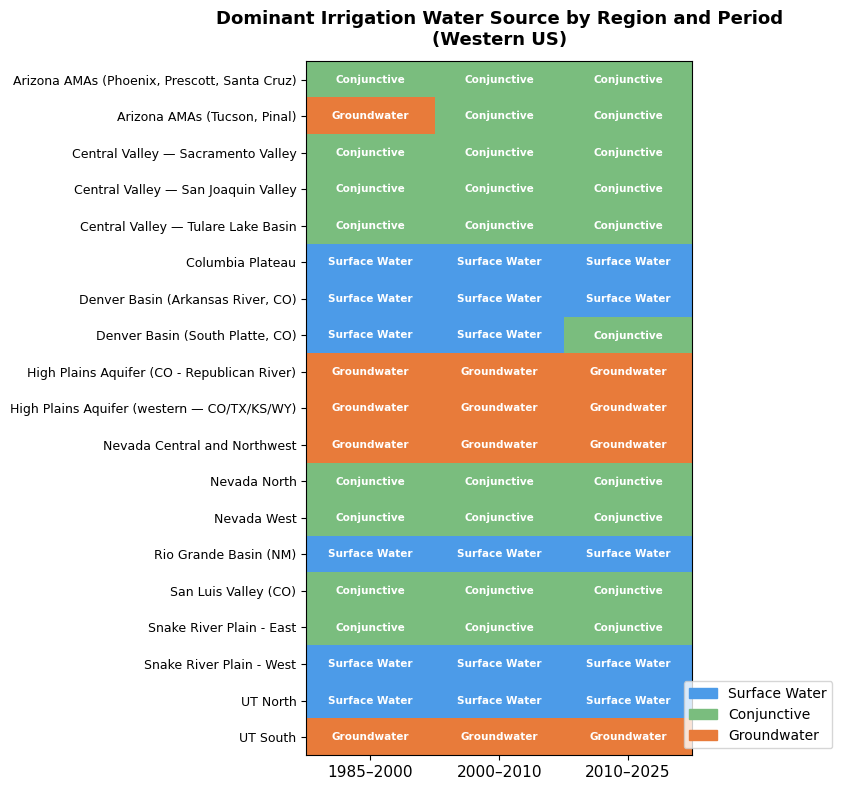

Figure 1 saved.


In [21]:
# ── Figure 1: Dominant source heatmap ──

color_sw = '#4C9BE8'   # blue  — surface water
color_gw = '#E87B3A'   # orange — groundwater
color_cj = '#7ABD7E'   # green  — conjunctive

source_colors = [color_sw, color_cj, color_gw]
source_labels  = ['Surface Water', 'Conjunctive', 'Groundwater']

def src_to_num(label):
    if 'Groundwater' in label:  return 2
    elif 'Surface Water' in label: return 0
    else: return 1  # Conjunctive

regions = list(pivot_source.index)

pivot_num = pivot_source.copy()
for col in pivot_num.columns:
    pivot_num[col] = pivot_num[col].apply(src_to_num)

from matplotlib.colors import ListedColormap
cmap_custom = ListedColormap(source_colors)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(pivot_num.values.astype(float), cmap=cmap_custom, vmin=0, vmax=2, aspect='auto')

ax.set_xticks(np.arange(len(period_order)))
ax.set_xticklabels(period_order, fontsize=11)
ax.set_yticks(np.arange(len(regions)))
ax.set_yticklabels(regions, fontsize=9)
ax.set_title('Dominant Irrigation Water Source by Region and Period\n(Western US)',
             fontsize=13, fontweight='bold', pad=12)

# Annotate each cell with the classification label
for i in range(len(regions)):
    for j, period in enumerate(period_order):
        val = pivot_source.iloc[i][period] if period in pivot_source.columns else ''
        if val:
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=7.5, fontweight='bold', color='white')

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(source_colors, source_labels)]
ax.legend(handles=patches, loc='lower right', bbox_to_anchor=(1.38, 0), fontsize=10)

plt.tight_layout()
plt.savefig('/Users/mdfahimhasan/Documents/PROJECTS/WestUS_IWU_trend/Data_main/Literature_water_source/summary/dominant_source_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')


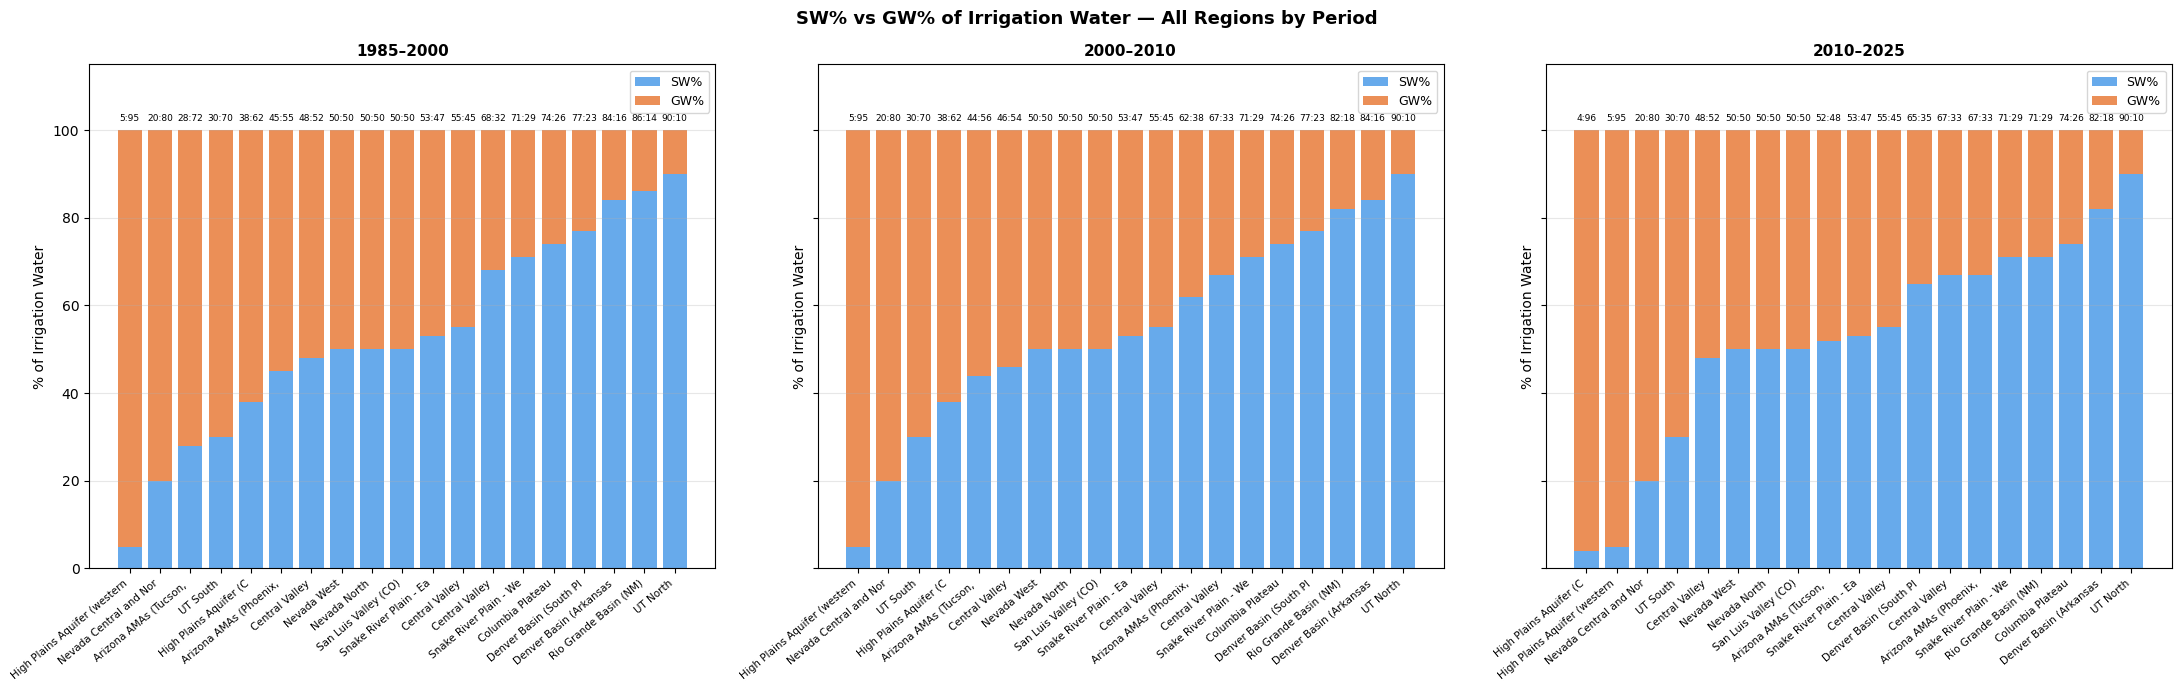

Figure 2 saved.


In [23]:
# ── Figure 2: SW% vs GW% stacked bar — all regions per period ──

fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)
fig.suptitle('SW% vs GW% of Irrigation Water — All Regions by Period',
             fontsize=13, fontweight='bold')

for idx, period in enumerate(period_order):
    sub = df[df['Period'] == period].sort_values('GW_pct', ascending=False)
    ax = axes[idx]
    x = np.arange(len(sub))
    ax.bar(x, sub['SW_pct'].values, color=color_sw, alpha=0.85, label='SW%')
    ax.bar(x, sub['GW_pct'].values, bottom=sub['SW_pct'].values,
           color=color_gw, alpha=0.85, label='GW%')
    ax.set_xticks(x)
    short_names = []
    for r in sub['Region'].values:
        if '—' in r:      # em-dash
            short_names.append(r.split('—')[0].strip())
        elif '(' in r:
            short_names.append(r[:22])
        else:
            short_names.append(r[:22])
    ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=7.5)
    ax.set_ylim(0, 115)
    ax.set_ylabel('% of Irrigation Water', fontsize=10)
    ax.set_title(period, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    for j, (sw, gw) in enumerate(zip(sub['SW_pct'].values, sub['GW_pct'].values)):
        ax.text(j, 102, f'{sw}:{gw}', ha='center', fontsize=6.5, color='black')

plt.tight_layout()
plt.savefig('/Users/mdfahimhasan/Documents/PROJECTS/WestUS_IWU_trend/Data_main/Literature_water_source/summary/sw_gw_ratio_all_regions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')


---
## 6. Export Summary CSV

In [26]:
# Export the compiled dataset to CSV for GIS/further analysis
csv_path = 'western_US_irrigation_water_sources_summary.csv'

# Clean Unicode characters for Excel compatibility
_uc_map = {'—': '--', '–': '-', '✓': '(ok)', '✗': '(fail)', '≤': '<='}
def _clean_unicode(v):
    return ''.join(_uc_map.get(c, c) for c in v) if isinstance(v, str) else v
df_csv = df.apply(lambda col: col.map(_clean_unicode) if col.dtype == object else col)
df_csv.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'Data exported to: {csv_path}')

# Also export the pivot tables
pivot_source.to_csv('/Users/mdfahimhasan/Documents/PROJECTS/WestUS_IWU_trend/Data_main/Literature_water_source/summary/dominant_source_pivot.csv', encoding='utf-8-sig')
pivot_sw.to_csv('/Users/mdfahimhasan/Documents/PROJECTS/WestUS_IWU_trend/Data_main/Literature_water_source/summary/sw_pct_pivot.csv', encoding='utf-8-sig')
pivot_gw.to_csv('/Users/mdfahimhasan/Documents/PROJECTS/WestUS_IWU_trend/Data_main/Literature_water_source/summary/gw_pct_pivot.csv', encoding='utf-8-sig')
print('Pivot tables exported.')

Data exported to: western_US_irrigation_water_sources_summary.csv
Pivot tables exported.


## Full Citations

### California — Central Valley
1. **Faunt, C.C., ed. (2009).** Groundwater Availability of the Central Valley Aquifer, California. *USGS Professional Paper 1766*. https://pubs.usgs.gov/pp/1766/
2. **The Nature Conservancy / Science for Conservation (2016).** Groundwater-Surface Water Interaction in California's Central Valley. https://www.scienceforconservation.org/assets/downloads/GroundwaterStreamInteraction_2016.pdf
3. **USGS California Water Science Center.** Sacramento Valley Groundwater Basin. https://ca.water.usgs.gov/projects/central-valley/sacramento-valley.html
4. **USGS California Water Science Center.** San Joaquin Valley Groundwater. https://ca.water.usgs.gov/projects/central-valley/san-joaquin-basin.html
5. **Northern California Water Association (NCWA).** Sacramento Valley Water Management Program. https://www.norcalwater.org/res/docs/NCWA_supp-web.pdf

### Arizona — AMAs
6. **ADWR — Arizona Department of Water Resources.** AMA Annual Water Supply and Demand Dashboards (Active Management Areas). https://www.azwater.gov/ama/ama-data

### Nevada
7. **Lopes, T.J., and Evetts, D.M. (2004).** Ground-water use and simulated effects of ground-water irrigation in the Humboldt River Basin, northern Nevada. *USGS Water-Resources Investigations Report 03-4156*.
8. **Truckee-Carson Irrigation District (TCID).** About TCID. https://www.tcid.org/about
9. **USBR — Bureau of Reclamation.** Newlands Project (Truckee-Carson). https://www.usbr.gov/projects/index.php?id=463
10. **USGS Nevada Water Science Center.** Groundwater Budgets and Chemical Characterization. https://www.usgs.gov/centers/nevada-water-science-center/science/budgets-and-chemical-characterization-groundwater

### San Luis Valley — Colorado
11. **Ivahnenko, T., Brandt, J.T., and Arnold, L.R. (2021).** Estimated water use in Colorado, 2015. *USGS Scientific Investigations Report 2021-5036*, Tables 8–9, Figure 5. https://doi.org/10.3133/sir20215036
12. **CO DWR — Colorado Division of Water Resources, Division 3.** Water use statistics, San Luis Valley.
13. **Fatta, J.M., et al. (2026, in prep).** Irrigation water-source trends in the San Luis Valley, Colorado.

### Rio Grande Basin — New Mexico
14. **Ivahnenko, T., Brandt, J.T., and Arnold, L.R. (2021).** Estimated water use in Colorado, 2015. *USGS Scientific Investigations Report 2021-5036*, Tables 8–9, Figure 5. (Rio Grande section includes NM data.) https://doi.org/10.3133/sir20215036

### High Plains Aquifer
15. **McGuire, V.L. (2011).** Water-level changes in the High Plains aquifer, predevelopment to 2009, 2007–08, and 2008–09, and change in water in storage, predevelopment to 2009. *USGS Scientific Investigations Report 2011-5089*. https://pubs.usgs.gov/sir/2011/5089/
16. **McGuire, V.L. (2023).** Water-level and storage changes in the High Plains aquifer, predevelopment to 2021 and 2019–21. *USGS Scientific Investigations Report 2023-5001*. https://doi.org/10.3133/sir20235001

### Utah — South
17. **Marston, T.M. (2017).** Hydrogeology and simulated groundwater flow in the Parowan Valley, Iron County, Utah. *USGS Scientific Investigations Report 2017-5033*. https://pubs.usgs.gov/sir/2017/5033/sir20175033.pdf
18. **Brooks, L.E., and Marston, T.M. (2005).** Hydrogeology and simulated effects of proposed ground-water withdrawals from the Cedar Valley aquifer, Iron County, Utah. *USGS Scientific Investigations Report 2005-5170*. https://pubs.usgs.gov/sir/2005/5170/PDF/SIR2005_5170.pdf
19. **Gardner, P.M., et al. (2019).** Hydrogeology of the Wah Wah Valley, Pine Valley, and Pine Creek areas, Beaver and Millard Counties, Utah. *USGS Scientific Investigations Report 2019-5139*. https://pubs.usgs.gov/sir/2019/5139/sir20195139.pdf

### Utah — North
20. **UDWR — Utah Division of Water Resources (2010).** Jordan River Basin State Water Plan. https://water.utah.gov/wp-content/uploads/2019/SWP/JordanRiver/Jordan-River-Basin-Final2010.pdf
21. **Isaacson, J.R. (2004).** Water Resources of Utah. *Utah Geological Survey Notes*, Jul–Aug 2004. https://d36oiwf74r1rap.cloudfront.net/wp-content/uploads/2015/09/Jul-Aug-2004.pdf

### Pacific Northwest — Columbia Plateau
22. **Kahle, S.C., et al. (2011).** Estimated water use for irrigation in the Pacific Northwest, 2000 and 2005. *USGS Scientific Investigations Report 2011-5124*, Figure 9. https://pubs.usgs.gov/sir/2011/5124/

### Pacific Northwest — Snake River Plain
23. **Clark, W.E., et al. (1998).** Hydrologic conditions and water-use trends in the Snake River basin, Idaho. *(Full reference to be confirmed — source cited for GW-SW split data.)*
24. **Idaho Department of Water Resources (2015).** Idaho Water Use, 2015 — Fact Sheet.

### Colorado — Eastern Basins (CDSS data)
25. **Colorado Division of Water Resources (CDWR) / Colorado's Decision Support System (CDSS).** Irrigated Lands GIS data — irrigated area by irrigation method (flood vs. sprinkler), snapshot years 2010, 2015, 2020. Hand-calculated SW/GW fractions: flood irrigation treated as surface-water proxy, sprinkler as groundwater proxy. https://cdss.colorado.gov/
